# Autoencoder para Detección de Fraude con Tarjetas de Crédito

Este notebook implementa un autoencoder en TensorFlow para el dataset de fraude [link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data).

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from matplotlib import pyplot as plt

## Cargar dataset

In [3]:
df = pd.read_csv('../data/creditcard.csv')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values per column:
Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
V11       0
V10       0
V9        0
V8        0
V7        0
V6        0
V5        0
V4        0
V3        0
V2        0
Class     0
dtype: int64


In [7]:
print("\nClass distribution:")
print(df['Class'].value_counts(normalize=True).rename('proportion'))


Class distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [8]:
X = df.drop('Class', axis=1).values
y = df['Class'].values

## Preprocesamiento

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## División de train/test y selección de datos normales

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]

## Modelo Autoencoder

In [11]:
input_dim = X_train_normal.shape[1]
inputs = tf.keras.Input(shape=(input_dim,))
encoded = tf.keras.layers.Dense(16, activation='relu')(inputs)
encoded = tf.keras.layers.Dense(8, activation='relu')(encoded)

bottleneck = tf.keras.layers.Dense(4, activation='relu')(encoded)

decoded = tf.keras.layers.Dense(8, activation='relu')(bottleneck)
decoded = tf.keras.layers.Dense(16, activation='relu')(decoded)
outputs = tf.keras.layers.Dense(input_dim, activation='linear')(decoded)


autoencoder = tf.keras.Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

I0000 00:00:1767752740.603848   86680 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


## Entrenamiento

In [12]:
history = autoencoder.fit(X_train_normal, X_train_normal, epochs=20, batch_size=256, validation_split=0.1, shuffle=True)

Epoch 1/20


I0000 00:00:1767752742.781440  211343 service.cc:152] XLA service 0x7e9b3800c890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767752742.781471  211343 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2026-01-06 20:25:42.834834: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767752743.085795  211343 cuda_dnn.cc:529] Loaded cuDNN version 91001
2026-01-06 20:25:45.485687: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_473', 4 bytes spill stores, 4 bytes spill loads

2026-01-06 20:25:45.769644: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot

 77/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0060

I0000 00:00:1767752749.626159  211343 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


800/800 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.8854 - val_loss: 0.7313
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7122 - val_loss: 0.6563
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6556 - val_loss: 0.6448
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6389 - val_loss: 0.6171
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6219 - val_loss: 0.6059
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6098 - val_loss: 0.5921
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5965 - val_loss: 0.5778
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5813 - val_loss: 0.5666
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5696 - val_loss: 0.5600
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5634 - val_loss: 0.5544
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5622 - val_loss: 0.5504
Epoch 12/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 

In [28]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
])

/home/gibran/anaconda3/envs/tf219/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model2

<Sequential name=sequential, built=True>

In [30]:
w1 = autoencoder.layers[1].get_weights()
w2 = autoencoder.layers[2].get_weights()
w3 = autoencoder.layers[3].get_weights()

In [34]:
model2.layers[0].set_weights(w1)
model2.layers[1].set_weights(w2)
model2.layers[2].set_weights(w3)

In [36]:
X_train_normal[:1]

array([[ 1.02211246,  0.99813578, -0.23059493, -0.20775754,  0.23318268,
        -0.36904644, -0.06469975, -0.50762449,  0.03013664,  0.95988654,
        -0.02795739,  0.61231399,  1.69285059,  1.26175537, -0.2642062 ,
        -0.36238366,  0.35064408, -1.09596692,  0.77748202,  0.20636189,
        -0.16264904,  0.32428871,  1.3343042 ,  0.08520655, -0.46000718,
        -0.0863251 , -0.4495408 ,  0.11190459, -0.14282722, -0.31328851]])

In [37]:
model2(X_train_normal[:1])

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=array([[3.7782927, 3.01954  , 1.9891521, 2.5947278]], dtype=float32)>

## Errores de reconstrucción y umbral

7108/7108 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step


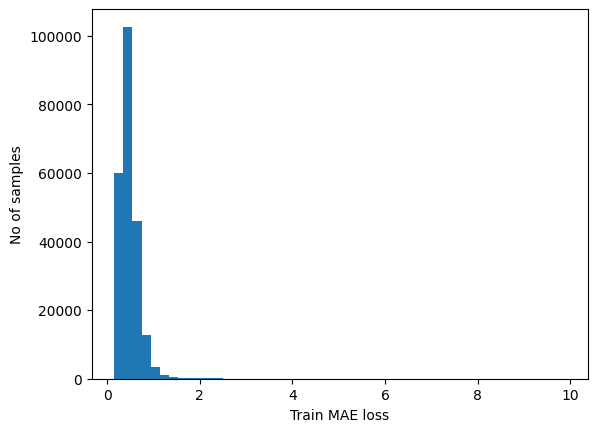

In [13]:
x_train_pred = autoencoder.predict(X_train_normal)
train_mae_loss = np.mean(np.abs(x_train_pred - X_train_normal), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

In [14]:
threshold = np.quantile(train_mae_loss, [0.99])[0]
threshold

1.176675660509145

In [15]:
X_test_pred = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.abs(X_test - X_test_pred), axis=1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [16]:
reconstruction_error

array([5.91726023, 0.58601031, 0.3690793 , ..., 0.65458633, 0.30427824,
       1.08751492])

## Clasificación y métricas

In [17]:
y_pred = (reconstruction_error > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.81      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.90      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [18]:
print(confusion_matrix(y_test, y_pred))

[[56268   596]
 [   19    79]]


In [19]:
y_pred = (reconstruction_error > 0.5).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.63      0.77     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.63     56962
   macro avg       0.50      0.80      0.39     56962
weighted avg       1.00      0.63      0.77     56962



In [20]:
print(confusion_matrix(y_test, y_pred))

[[35767 21097]
 [    2    96]]
